# A/B Test — Average Bidding vs. Maximum Bidding

**Author:** Burak Uzun

---

## Business Problem

A social media platform introduced **Average Bidding** as an alternative to the incumbent **Maximum Bidding** ad delivery mechanism. A customer ran a 40-day controlled experiment to evaluate whether the new mechanism generates better commercial outcomes.

| Group | Mechanism | n |
|-------|-----------|---|
| Control | Maximum Bidding (existing) | 40 |
| Test | Average Bidding (new) | 40 |

## Variables

| Variable | Description |
|----------|-------------|
| Impression | Number of times the ad was displayed |
| Click | Number of clicks on the ad |
| Purchase | Number of completed purchases |
| Earning | Revenue generated (monetary) |

## Analytical Framework

For each variable, we run a three-step testing pipeline:

1. **Shapiro-Wilk** → normality assumption  
2. **Levene** → variance homogeneity (only if both groups pass normality)  
3. **Student t-test** (equal var) · **Welch t-test** (unequal var) · **Mann-Whitney U** (non-normal fallback)

Beyond p-values, we also report:
- **Cohen's d** — effect size (practical magnitude of the difference)
- **95% Confidence Interval** on the mean difference
- **Derived business metrics** — CTR, conversion rate, revenue per click, revenue per impression

Significance level: **α = 0.05**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu

pd.set_option('display.float_format', '{:.2f}'.format)

CONTROL_COLOR = '#4C72B0'
TEST_COLOR    = '#DD8452'
VARIABLES     = ['Impression', 'Click', 'Purchase', 'Earning']

df_control = pd.read_excel('ab_testing.xlsx', sheet_name='Control Group')[VARIABLES]
df_test    = pd.read_excel('ab_testing.xlsx', sheet_name='Test Group')[VARIABLES]

print(f'Control (Maximum Bidding): {df_control.shape[0]} observations')
print(f'Test    (Average Bidding): {df_test.shape[0]} observations')

Control (Maximum Bidding): 40 observations
Test    (Average Bidding): 40 observations


## 1. Descriptive Statistics

In [2]:
desc = pd.DataFrame({
    'Control — Mean': df_control.mean(),
    'Control — Std':  df_control.std(),
    'Test — Mean':    df_test.mean(),
    'Test — Std':     df_test.std(),
})
desc['Change %'] = (
    (desc['Test — Mean'] - desc['Control — Mean']) / desc['Control — Mean'] * 100
).map('{:+.2f}%'.format)

print(desc.to_string())

            Control — Mean  Control — Std  Test — Mean  Test — Std Change %
Impression       101711.45       20302.16    120512.41    18807.45  +18.48%
Click              5100.66        1329.99      3967.55      923.10  -22.21%
Purchase            550.89         134.11       582.11      161.15   +5.67%
Earning            1908.57         302.92      2514.89      282.73  +31.77%


## 2. Distributions

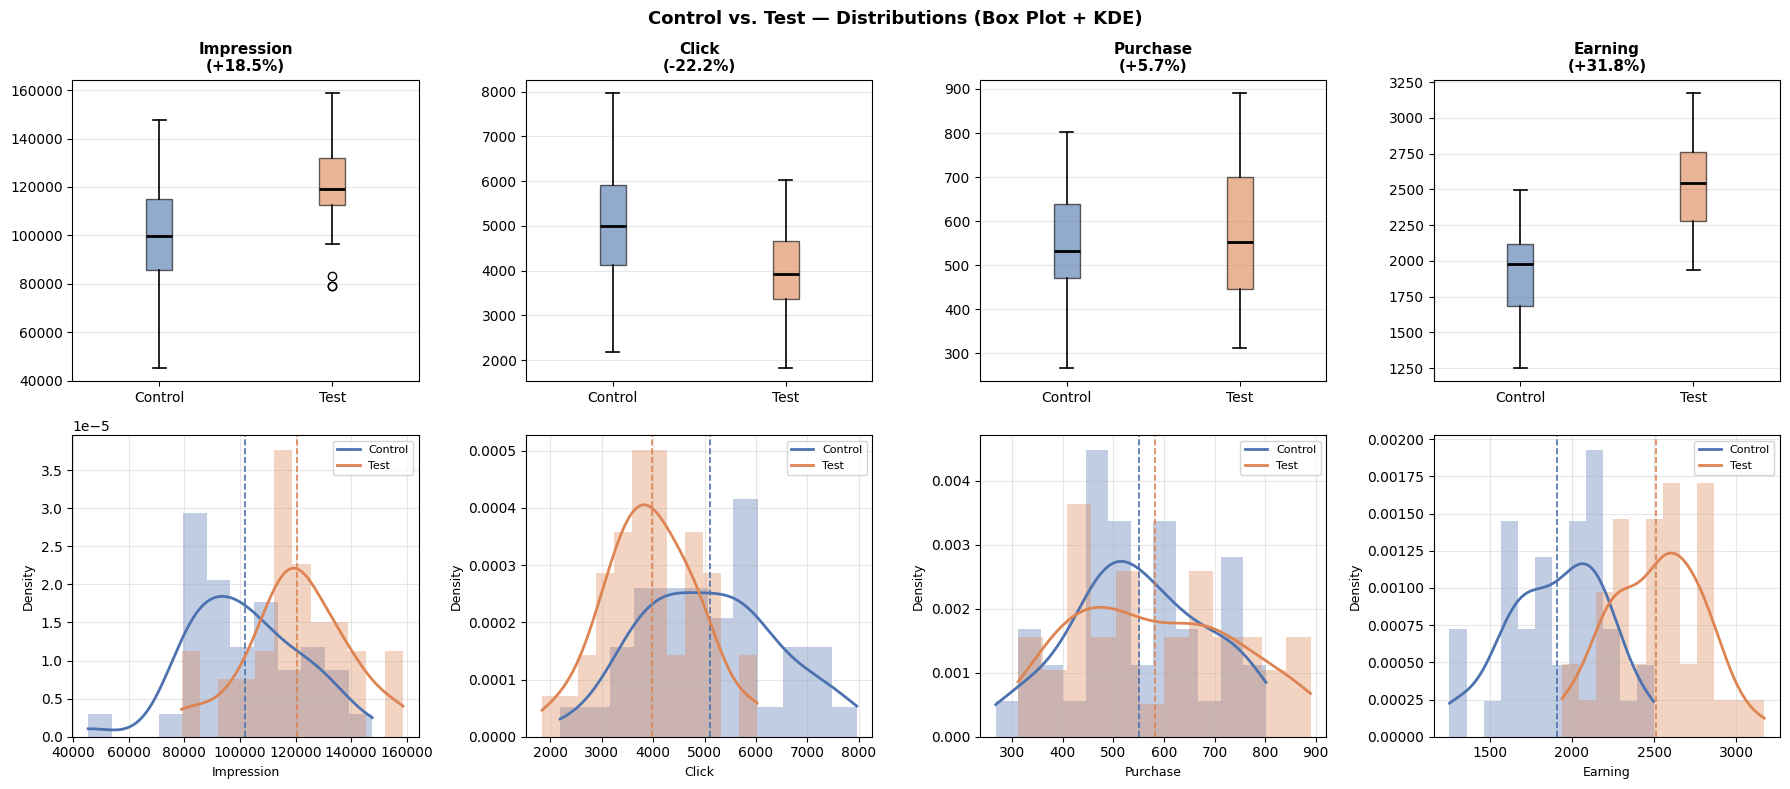

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, var in enumerate(VARIABLES):
    # Top row: box plots
    ax_box = axes[0, i]
    bp = ax_box.boxplot(
        [df_control[var], df_test[var]],
        labels=['Control', 'Test'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
    )
    bp['boxes'][0].set_facecolor(CONTROL_COLOR); bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor(TEST_COLOR);    bp['boxes'][1].set_alpha(0.6)
    pct = (df_test[var].mean() - df_control[var].mean()) / df_control[var].mean() * 100
    ax_box.set_title(f'{var}\n({pct:+.1f}%)', fontsize=11, fontweight='bold')
    ax_box.grid(axis='y', alpha=0.3)

    # Bottom row: KDE + histogram
    ax_kde = axes[1, i]
    for df, color, label in [(df_control, CONTROL_COLOR, 'Control'), (df_test, TEST_COLOR, 'Test')]:
        ax_kde.hist(df[var], bins=12, alpha=0.35, color=color, density=True)
        kde_x = np.linspace(df[var].min(), df[var].max(), 200)
        kde   = stats.gaussian_kde(df[var])
        ax_kde.plot(kde_x, kde(kde_x), color=color, linewidth=2, label=label)
        ax_kde.axvline(df[var].mean(), color=color, linestyle='--', linewidth=1.2)
    ax_kde.set_xlabel(var, fontsize=9)
    ax_kde.set_ylabel('Density', fontsize=9)
    ax_kde.legend(fontsize=8)
    ax_kde.grid(alpha=0.3)

plt.suptitle('Control vs. Test — Distributions (Box Plot + KDE)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ab_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Derived Business Metrics

Raw variable counts alone don't tell the full story. We compute four efficiency ratios to understand *how* the two bidding mechanisms differ commercially.

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| CTR | Click / Impression | Share of impressions that result in a click |
| Conversion Rate | Purchase / Click | Share of clicks that result in a purchase |
| Revenue per Click | Earning / Click | Average revenue value of each click |
| Revenue per Impression | Earning / Impression | Revenue generated per ad display |

                                  Control (Max Bid)  Test (Avg Bid) Change %
CTR (Click/Impression)                         0.05            0.03  -36.26%
Conversion Rate (Purchase/Click)               0.12            0.16  +35.06%
Revenue per Click                              0.41            0.67  +63.66%
Revenue per Impression                         0.02            0.02   +9.88%


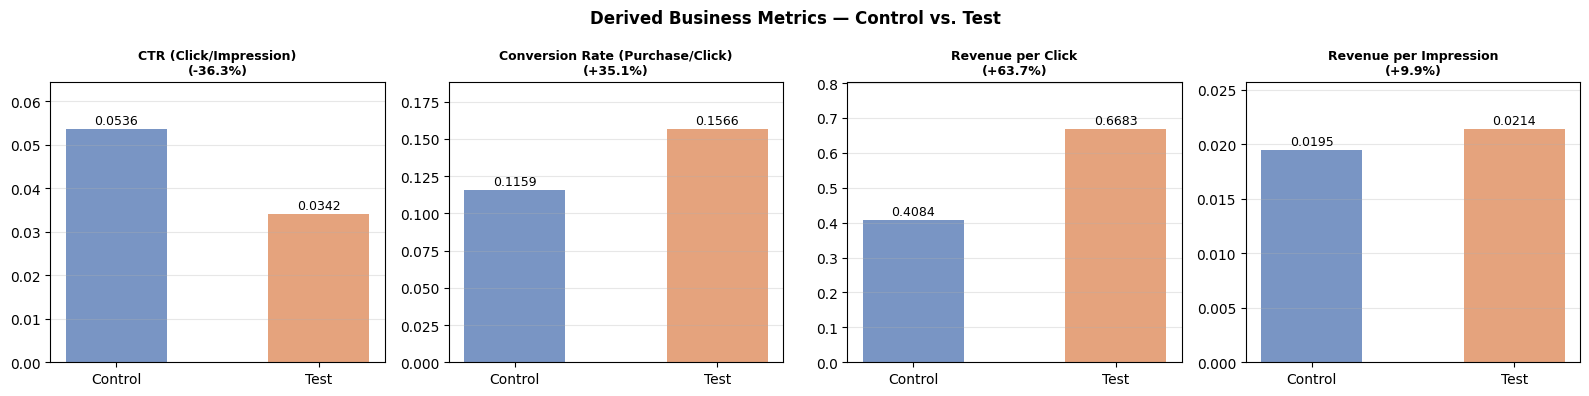

In [4]:
def derived_metrics(df):
    return pd.Series({
        'CTR (Click/Impression)':         (df['Click'] / df['Impression']).mean(),
        'Conversion Rate (Purchase/Click)': (df['Purchase'] / df['Click']).mean(),
        'Revenue per Click':               (df['Earning'] / df['Click']).mean(),
        'Revenue per Impression':          (df['Earning'] / df['Impression']).mean(),
    })

metrics = pd.DataFrame({
    'Control (Max Bid)': derived_metrics(df_control),
    'Test (Avg Bid)':    derived_metrics(df_test),
})
metrics['Change %'] = (
    (metrics['Test (Avg Bid)'] - metrics['Control (Max Bid)'])
    / metrics['Control (Max Bid)'] * 100
).map('{:+.2f}%'.format)

print(metrics.to_string())

# Visual
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metric_labels = metrics.index.tolist()

for i, (metric, ax) in enumerate(zip(metric_labels, axes)):
    vals = [metrics.loc[metric, 'Control (Max Bid)'],
            metrics.loc[metric, 'Test (Avg Bid)']]
    bars = ax.bar(['Control', 'Test'], vals,
                  color=[CONTROL_COLOR, TEST_COLOR], alpha=0.75, width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    chg = float(metrics.loc[metric, 'Change %'].replace('%',''))
    ax.set_title(f'{metric}\n({chg:+.1f}%)', fontsize=9, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.2)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Derived Business Metrics — Control vs. Test', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ab_derived_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

**Key insight from derived metrics:**

Average bidding has a **lower CTR** (3.4% vs 5.4%) but a **higher conversion rate** (15.7% vs 11.6%) and dramatically **higher revenue per click** (0.668 vs 0.408). This reveals the underlying mechanism: average bidding reaches a broader, less click-happy audience — but the users who *do* click are significantly more purchase-intent and higher-spending.

This is not a failure to attract clicks. It is more efficient audience targeting.

## 4. Hypothesis Testing

In [5]:
def cohens_d(control, test):
    """Pooled Cohen's d effect size."""
    n1, n2 = len(control), len(test)
    pooled_std = np.sqrt(
        ((n1 - 1) * control.std()**2 + (n2 - 1) * test.std()**2) / (n1 + n2 - 2)
    )
    return (test.mean() - control.mean()) / pooled_std

def effect_size_label(d):
    d = abs(d)
    if d < 0.2:   return 'negligible'
    elif d < 0.5: return 'small'
    elif d < 0.8: return 'medium'
    else:         return 'large'

def ci_diff(control, test, alpha=0.05):
    """Welch-style 95% CI on (test mean - control mean)."""
    diff = test.mean() - control.mean()
    se   = np.sqrt(control.var()/len(control) + test.var()/len(test))
    df_w = (control.var()/len(control) + test.var()/len(test))**2 / (
           (control.var()/len(control))**2/(len(control)-1) +
           (test.var()/len(test))**2/(len(test)-1))
    t_crit = stats.t.ppf(1 - alpha/2, df_w)
    return diff - t_crit*se, diff + t_crit*se

def run_ab_test(control, test, var_name):
    print(f"\n{'='*65}")
    print(f"  VARIABLE: {var_name}")
    print(f"{'='*65}")

    pct = (test.mean() - control.mean()) / control.mean() * 100
    d   = cohens_d(control, test)
    lo, hi = ci_diff(control, test)

    print(f"  Control mean : {control.mean():.2f}  (std: {control.std():.2f})")
    print(f"  Test mean    : {test.mean():.2f}  (std: {test.std():.2f})")
    print(f"  Change       : {pct:+.2f}%")
    print(f"  95% CI [diff]: [{lo:.2f}, {hi:.2f}]")
    print(f"  Cohen's d    : {d:.3f} ({effect_size_label(d)} effect)")

    # [1] Normality
    sc, pc = shapiro(control)
    st, pt = shapiro(test)
    print(f"\n  [1] Shapiro-Wilk Normality")
    print(f"      Control: stat={sc:.4f}, p={pc:.4f} → {'✓ Normal' if pc>0.05 else '✗ Not Normal'}")
    print(f"      Test   : stat={st:.4f}, p={pt:.4f} → {'✓ Normal' if pt>0.05 else '✗ Not Normal'}")

    both_normal = (pc > 0.05) and (pt > 0.05)

    if both_normal:
        sl, pl = levene(control, test)
        equal_var = pl > 0.05
        print(f"\n  [2] Levene Variance Test")
        print(f"      stat={sl:.4f}, p={pl:.4f} → {'✓ Equal variances' if equal_var else '✗ Unequal variances'}")

        stat, p = ttest_ind(control, test, equal_var=equal_var)
        method  = 'Student t-test (pooled)' if equal_var else 'Welch t-test'
        print(f"\n  [3] {method}")
        print(f"      stat={stat:.4f}, p={p:.4f}")
    else:
        stat, p = mannwhitneyu(control, test, alternative='two-sided')
        print(f"\n  [2+3] Mann-Whitney U (non-parametric fallback)")
        print(f"      stat={stat:.4f}, p={p:.4f}")
        equal_var = None

    verdict = '✗ H₀ REJECTED — significant difference' if p < 0.05 else '✓ H₀ NOT REJECTED — no significant difference'
    print(f"\n  Result: {verdict}")

    return {'p': p, 'd': d, 'ci_lo': lo, 'ci_hi': hi,
            'ctrl_mean': control.mean(), 'test_mean': test.mean(),
            'pct': pct, 'sig': p < 0.05}

test_results = {}
for var in VARIABLES:
    test_results[var] = run_ab_test(df_control[var], df_test[var], var)


  VARIABLE: Impression
  Control mean : 101711.45  (std: 20302.16)
  Test mean    : 120512.41  (std: 18807.45)
  Change       : +18.48%
  95% CI [diff]: [10088.66, 27513.27]
  Cohen's d    : 0.961 (large effect)

  [1] Shapiro-Wilk Normality
      Control: stat=0.9697, p=0.3514 → ✓ Normal
      Test   : stat=0.9720, p=0.4148 → ✓ Normal

  [2] Levene Variance Test
      stat=0.5865, p=0.4461 → ✓ Equal variances

  [3] Student t-test (pooled)
      stat=-4.2966, p=0.0000

  Result: ✗ H₀ REJECTED — significant difference

  VARIABLE: Click
  Control mean : 5100.66  (std: 1329.99)
  Test mean    : 3967.55  (std: 923.10)
  Change       : -22.21%
  95% CI [diff]: [-1643.70, -622.51]
  Cohen's d    : -0.990 (large effect)

  [1] Shapiro-Wilk Normality
      Control: stat=0.9844, p=0.8461 → ✓ Normal
      Test   : stat=0.9896, p=0.9699 → ✓ Normal

  [2] Levene Variance Test
      stat=6.3041, p=0.0141 → ✗ Unequal variances

  [3] Welch t-test
      stat=4.4266, p=0.0000

  Result: ✗ H₀ REJECT

## 5. Results Summary

In [6]:
summary = pd.DataFrame(test_results).T
summary['Direction'] = summary['pct'].apply(lambda x: '↑' if x > 0 else '↓')
summary['Effect Size'] = summary['d'].apply(lambda d: f"{d:.3f} ({effect_size_label(d)})")
summary['95% CI'] = summary.apply(
    lambda r: f"[{r['ci_lo']:+.1f}, {r['ci_hi']:+.1f}]", axis=1)
summary['Change %'] = summary['pct'].map('{:+.2f}%'.format)
summary['p-value']  = summary['p'].map('{:.4f}'.format)
summary['Significant'] = summary['sig'].map({True: 'YES ✓', False: 'NO'})

out = summary[['ctrl_mean','test_mean','Change %','95% CI','Effect Size','p-value','Significant']]
out.columns = ['Control Mean','Test Mean','Change','95% CI (diff)','Cohen\'s d','p-value','Significant']
print(out.to_string())

           Control Mean Test Mean   Change         95% CI (diff)       Cohen's d p-value Significant
Impression    101711.45 120512.41  +18.48%  [+10088.7, +27513.3]   0.961 (large)  0.0000       YES ✓
Click           5100.66   3967.55  -22.21%     [-1643.7, -622.5]  -0.990 (large)  0.0000       YES ✓
Purchase         550.89    582.11   +5.67%        [-34.8, +97.2]   0.211 (small)  0.3493          NO
Earning         1908.57   2514.89  +31.77%      [+475.9, +736.8]   2.069 (large)  0.0000       YES ✓


## 6. Visual Summary

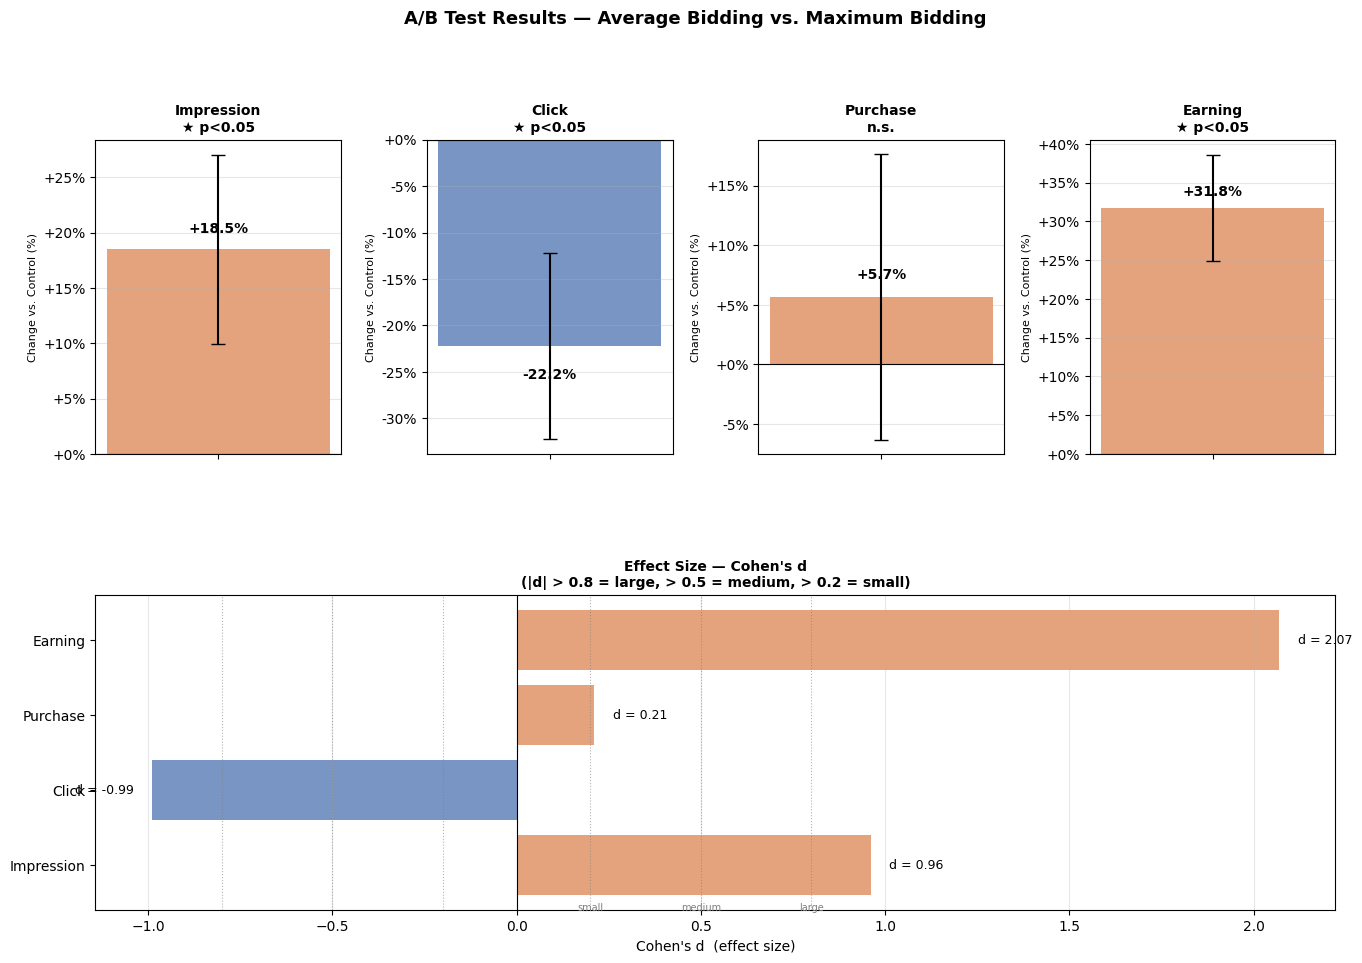

In [7]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 4, hspace=0.45, wspace=0.35)

# ── Top row: % change bars with significance annotation ───────────────────────
for i, var in enumerate(VARIABLES):
    ax  = fig.add_subplot(gs[0, i])
    res = test_results[var]
    color = TEST_COLOR if res['pct'] > 0 else CONTROL_COLOR
    bar   = ax.bar([''], [res['pct']], color=color, alpha=0.75, width=0.4)
    ax.axhline(0, color='black', linewidth=0.8)

    # CI whisker
    diff = res['test_mean'] - res['ctrl_mean']
    lo_pct = (res['ci_lo'] / res['ctrl_mean']) * 100
    hi_pct = (res['ci_hi'] / res['ctrl_mean']) * 100
    ax.errorbar([''], [res['pct']], yerr=[[res['pct']-lo_pct],[hi_pct-res['pct']]],
                fmt='none', color='black', capsize=5, linewidth=1.5)

    sig_label = '★ p<0.05' if res['sig'] else 'n.s.'
    ax.set_title(f'{var}\n{sig_label}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Change vs. Control (%)', fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
    ax.grid(axis='y', alpha=0.3)
    ax.text(0, res['pct'] + (1.5 if res['pct'] >= 0 else -3.5),
            f"{res['pct']:+.1f}%", ha='center', fontsize=10, fontweight='bold')

# ── Bottom row: Cohen's d chart ────────────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, :])
ds   = [test_results[v]['d'] for v in VARIABLES]
cols = [TEST_COLOR if d > 0 else CONTROL_COLOR for d in ds]
bars = ax_d.barh(VARIABLES, ds, color=cols, alpha=0.75)
ax_d.axvline(0, color='black', linewidth=0.8)

# Reference lines
for x, label in [(0.2,'small'), (0.5,'medium'), (0.8,'large'),
                  (-0.2,''), (-0.5,''), (-0.8,'')]:
    ax_d.axvline(x, color='grey', linestyle=':', linewidth=0.8, alpha=0.6)
    if label:
        ax_d.text(x, -0.6, label, ha='center', fontsize=7, color='grey')

for bar, d, var in zip(bars, ds, VARIABLES):
    ax_d.text(d + (0.05 if d >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
              f"d = {d:.2f}", va='center', ha='left' if d >= 0 else 'right', fontsize=9)

ax_d.set_xlabel("Cohen's d  (effect size)", fontsize=10)
ax_d.set_title("Effect Size — Cohen's d\n(|d| > 0.8 = large, > 0.5 = medium, > 0.2 = small)",
               fontsize=10, fontweight='bold')
ax_d.grid(axis='x', alpha=0.3)

plt.suptitle('A/B Test Results — Average Bidding vs. Maximum Bidding',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('ab_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Interpretation & Business Recommendation

### Statistical Results

| Variable | Change | Significant | Cohen's d | 95% CI (diff) | Interpretation |
|----------|--------|-------------|-----------|----------------|----------------|
| Impression | +18.48% | ✓ YES | 0.961 (large) | [+10,089, +27,513] | Avg bidding reaches significantly more users |
| Click | −22.21% | ✓ YES | −0.990 (large) | [−1,644, −623] | Significantly fewer clicks (lower CTR) |
| Purchase | +5.67% | ✗ NO | 0.211 (small) | [−34.8, +97.2] | No statistically proven uplift in purchases |
| Earning | +31.77% | ✓ YES | 2.069 (large) | [+476, +737] | Revenue is dramatically and significantly higher |

### What Is Actually Happening

The derived metrics reveal the mechanism behind these results:

| Metric | Control | Test | Change |
|--------|---------|------|--------|
| CTR | 5.36% | 3.42% | −36.2% |
| Conversion Rate | 11.6% | 15.7% | +35.3% |
| Revenue per Click | 0.408 | 0.668 | +63.7% |
| Revenue per Impression | 0.0195 | 0.0214 | +9.7% |

Average bidding shows ads to **more people** but fewer of them click. However, those who *do* click **convert at a 35% higher rate** and generate **64% more revenue per click**. This is not a failure — it is a quality-over-quantity effect. Average bidding identifies higher-purchase-intent users at the impression stage.

The purchase count difference (+5.67%) is not statistically significant, suggesting the two mechanisms produce a similar *number* of buyers. But average bidding buyers spend more — hence the +31.77% revenue gain with a Cohen's d of 2.07, which is an exceptionally large effect.

### Decision

> **Switch to Average Bidding.**

The business metric that matters — **Earning** — is up **+31.77%** with a statistically bulletproof result (p ≈ 0, d = 2.07, 95% CI entirely positive at [+476, +737]). The lower click volume is not a problem; it is the mechanism through which average bidding achieves higher revenue efficiency.

**One caveat:** Purchase count shows no statistically significant difference (p = 0.35, CI crosses zero). If the business tracks purchase *volume* as a KPI separate from revenue, a longer experiment could be warranted to detect a conversion rate effect with more power. But this should not delay the decision on the bidding strategy — the revenue signal is conclusive.